In [1]:
from math import factorial
import numpy as np

def pade_exp(m, n):

    # -------------------------------------------------
    # Série de Taylor de e^x
    # a_k = 1/k!
    # -------------------------------------------------

    order = m + n

    a = np.array(
        [1.0 / factorial(k) for k in range(order + 1)],
        dtype=float
    )

    # -------------------------------------------------
    # Resolver sistema linear para Q
    #
    # sum_j q_j a_{k-j} = 0
    #
    # para k = m+1 ... m+n
    # com q_0 = 1
    # -------------------------------------------------

    A = np.zeros((n, n))
    b = np.zeros(n)

    for row in range(n):

        k = m + 1 + row

        b[row] = -a[k]

        for col in range(n):

            j = col + 1

            A[row, col] = a[k - j]

    q_rest = np.linalg.solve(A, b)

    Q = np.concatenate(([1.0], q_rest))

    # -------------------------------------------------
    # Construir numerador
    #
    # P_k = sum_{j=0}^{min(k,n)} q_j a_{k-j}
    # -------------------------------------------------

    P = np.zeros(m + 1)

    for k in range(m + 1):

        s = 0.0

        for j in range(min(k, n) + 1):

            s += Q[j] * a[k - j]

        P[k] = s

    return P, Q

def get_P(n):
    p, q = pade_exp(n, n)
    return p

def get_Q(n):
    p, q = pade_exp(n, n)
    return q

In [2]:
def calc_newton_method_lut(grau_pade):
    from numpy.polynomial import polynomial as P

    Q = get_Q(grau_pade)

    x = np.array([-1.5, -0.5, 0.5, 1.5])
    y = P.polyval(x, Q)

    return np.array([1 / y[2], 1 / y[3], 1 / y[0], 1 / y[1]])

[ 1.         -0.5         0.1        -0.00833333]
[1.29205922 2.23776224 0.49921997 0.78367347]
[2.003125   1.27604167 0.77395833 0.446875  ]


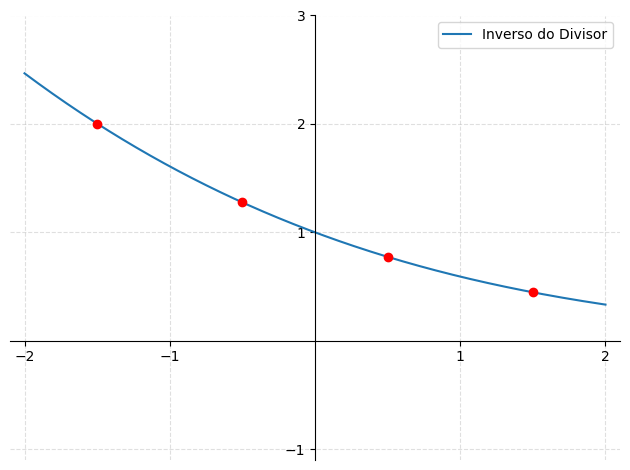

In [26]:
Q = get_Q(3)
print(Q)

lut = calc_newton_method_lut(3)
print(lut)

import math
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial import polynomial as P

x_min, x_max = -2, 2
y_min, y_max = -1, 3
step = 1

x = np.linspace(x_min, x_max, 500)
y = P.polyval(x, Q)

lut_x = np.array([-1.5, -0.5, 0.5, 1.5])
lut_y = P.polyval(lut_x, Q)

print(lut_y)

# eixos no centro
ax = plt.gca()
ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')

# ticks
xticks = np.arange(x_min, x_max + step, step)
yticks = np.arange(y_min, y_max + step, step)

xticks = xticks[xticks != 0]
yticks = yticks[yticks != 0]

plt.xticks(xticks)
plt.yticks(yticks)

# estilo
plt.grid(True, linestyle='--', alpha=0.4)
plt.xlim(x_min - 0.1, x_max + 0.1)
plt.ylim(y_min - 0.1, y_max)

plt.plot(x, y, label="Inverso do Divisor")

for (lx, ly) in zip(lut_x, lut_y):

    ax.plot(lx, ly, marker="o", color="red")

    # plt.axvline(
    #     x=lx + 0.5,               # posição da linha
    #     color='red',
    #     linestyle='--',    # pontilhada/tracejada
    #     linewidth=1.5
    # )

# plt.title(f"Valores Iniciais para Aproximação de Newton-Raphson", fontsize=14, pad=12)

plt.legend()
# plt.show()


plt.tight_layout()
plt.savefig(f"newton_lut_pade.pdf", format="pdf")
plt.show()

In [5]:
calc_newton_method_lut(1)

array([1.33333333, 4.        , 0.57142857, 0.8       ])

In [ ]:
from pharos_hls.pharos_hls import PharosHLS

In [ ]:
vitis_explore = PharosHLS("z_estudo_EXP")

In [ ]:
from pharos_hls.constraints import *
from pharos_hls.params import *

params = {
    "grau": Param(range=(1, 3)),
    "newton": Param(range=(1, 3))
}

function_params = {
    "input": FunctionParam("input_t", input_or_output=True),
    "output": FunctionParam("output_t", input_or_output=True),
    "padeP": CustomVectorParam("operation_t", "grau", get_P),
    "padeQ": CustomVectorParam("operation_t", "grau", get_Q),
    "newtonLUT": CustomVectorParam("operation_t", "grau", calc_newton_method_lut)
}

In [7]:
IMPL_FOLDER = "z_estudo_EXP_user_impl"

In [8]:
vitis_explore.define_function_to_explore("pade_without_unroll",
                                         f"{IMPL_FOLDER}/approx_exp_func.h",
                                         params,
                                         function_params,
                                         ("grau", "newton"))

In [9]:
vitis_explore.define_testbench(f"{IMPL_FOLDER}/testbench.cpp")

In [ ]:
vitis_explore.explore_synth(frequency_MHz=100, number_of_samples=9, part="xcu250-figd2104-2L-e", simulate_with_testbench=True)

In [11]:
tb_output = vitis_explore.get_tb_output("pade_without_unroll")

In [12]:
import math

gabarito = []
inc = 1 / 256
value = -2

for i in range(1024):
    gabarito.append(math.exp(value))
    value += inc

print(gabarito)

[0.1353352832366127, 0.13586497055877472, 0.1363967310184996, 0.13693057272981837, 0.13746650383851944, 0.13800453252227293, 0.13854466699075552, 0.13908691548577554, 0.13963128628139898, 0.1401777876840755, 0.14072642803276533, 0.1412772156990665, 0.14183015908734253, 0.14238526663485063, 0.14294254681187055, 0.14350200812183378, 0.14406365910145327, 0.1446275083208538, 0.14519356438370257, 0.14576183592734063, 0.1463323316229146, 0.14690506017550908, 0.1474800303242793, 0.14805725084258467, 0.1486367305381225, 0.14921847825306253, 0.14980250286418162, 0.15038881328299952, 0.1509774184559146, 0.15156832736434045, 0.1521615490248429, 0.1527570924892777, 0.15335496684492847, 0.15395518121464546, 0.15455774475698483, 0.15516266666634826, 0.15576995617312325, 0.15637962254382412, 0.1569916750812332, 0.15760612312454297, 0.15822297604949842, 0.15884224326854016, 0.15946393423094812, 0.16008805842298557, 0.16071462536804407, 0.16134364462678857, 0.1619751257973035, 0.1626090785152391, 0.163

In [14]:
def get_max_relative_abs_error(approx_values, real_values):
    max_error = -1
    idx = -1

    for i in range(len(real_values)):
        aux = abs(real_values[i] - approx_values[i]) / abs(real_values[i])

        if aux > max_error:
            max_error = aux
            idx = i

    return max_error, idx

def get_max_abs_error(approx_values, real_values):
    max_error = -1
    idx = -1

    for i in range(len(real_values)):
        aux = abs(real_values[i] - approx_values[i])

        if aux > max_error:
            max_error = aux
            idx = i

    return max_error, idx

def get_mse(approx_values, real_values):
    sum = 0

    for i in range(len(real_values)):
        aux = real_values[i] - approx_values[i]
        sum += aux * aux

    return sum / len(real_values)

tb_output.sort(key=lambda x: (x["config"]["grau"], x["config"]["newton"]))

for config_output in tb_output:

    if config_output['config']['grau'] == 1:
        continue

    max_relative, idx_relative = get_max_relative_abs_error(config_output['out'], gabarito)
    max_abs, idx_abs = get_max_abs_error(config_output['out'], gabarito)
    mse = get_mse(config_output['out'], gabarito)

    print(f"{config_output['config']}: max relative error ({-2 + idx_relative / 256: .4f}): {max_relative: .4f}   -   max absolute error ({-2 + idx_abs/ 256: .4f}): {max_abs: .4f}  -  MSE: {mse:.4f}")


{'grau': 2, 'newton': 1}: max relative error ( 1.0000):  0.1123   -   max absolute error ( 1.9961):  0.7704  -  MSE: 0.0204
{'grau': 2, 'newton': 2}: max relative error ( 1.9961):  0.0541   -   max absolute error ( 1.9961):  0.3978  -  MSE: 0.0051
{'grau': 2, 'newton': 3}: max relative error (-2.0000):  0.0535   -   max absolute error ( 1.9961):  0.3756  -  MSE: 0.0047
{'grau': 3, 'newton': 1}: max relative error ( 1.0000):  0.1041   -   max absolute error ( 1.9961):  0.4303  -  MSE: 0.0070
{'grau': 3, 'newton': 2}: max relative error ( 1.0000):  0.0105   -   max absolute error ( 1.8867):  0.0356  -  MSE: 0.0001
{'grau': 3, 'newton': 3}: max relative error ( 1.9883):  0.0089   -   max absolute error ( 1.9883):  0.0649  -  MSE: 0.0002


In [39]:
grau_2 = [tb_output[3]['out'], tb_output[4]['out'], tb_output[5]['out']]

In [34]:
grau_3 = [tb_output[6]['out'], tb_output[7]['out'], tb_output[8]['out']]

In [16]:
import matplotlib.pyplot as plt

def plot_listas(listas):
    """
    Recebe uma lista de listas de mesmo tamanho
    e faz subplots lado a lado.
    """

    if not listas:
        raise ValueError("A lista está vazia")

    tamanho = len(listas[0])

    for lista in listas:
        if len(lista) != tamanho:
            raise ValueError("Todas as listas devem ter o mesmo tamanho")

    x = range(tamanho)

    n = len(listas)

    fig, axs = plt.subplots(1, n, figsize=(5*n, 4))

    # Caso exista apenas uma lista
    if n == 1:
        axs = [axs]

    for i, lista in enumerate(listas):
        axs[i].plot(x, lista)

        axs[i].set_title(f"Lista {i}")
        axs[i].set_xlabel("Índice")
        axs[i].set_ylabel("Valor")
        axs[i].grid(True)

    plt.tight_layout()
    plt.show()

In [29]:
import matplotlib.pyplot as plt

def plot_listas_with_overlap(listas):
    """
    Recebe uma lista de listas de mesmo tamanho
    e plota cada uma delas.
    """

    if not listas:
        raise ValueError("A lista está vazia")

    tamanho = len(listas[0])

    for lista in listas:
        if len(lista) != tamanho:
            raise ValueError("Todas as listas devem ter o mesmo tamanho")

    x = range(tamanho)

    for i, lista in enumerate(listas):
        plt.plot(x, lista, label=f"Lista {i}")

    plt.xlabel("Índice")
    plt.ylabel("Valor")
    plt.title("Plot das listas")
    plt.legend()
    plt.grid(True)

    plt.show()

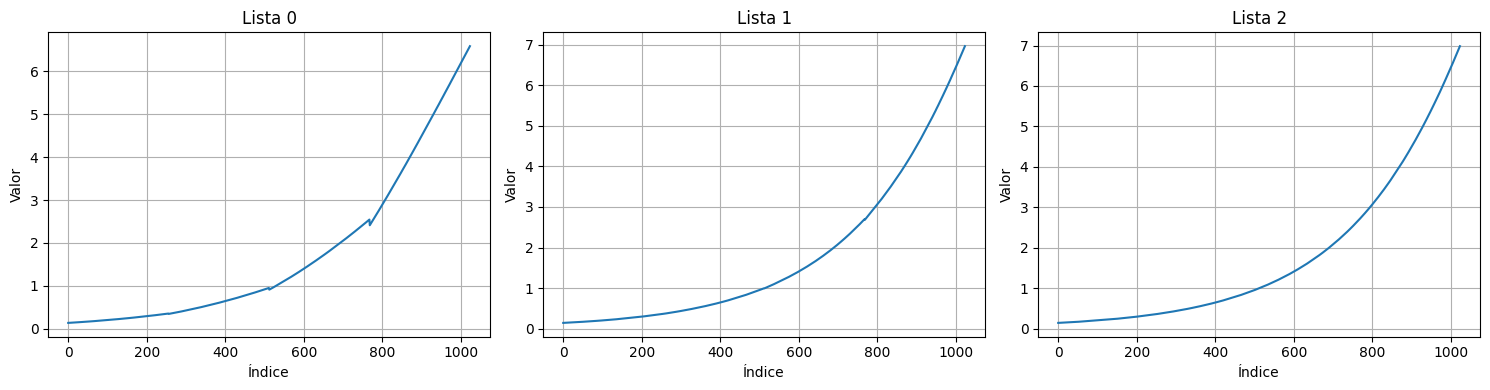

In [40]:
plot_listas(grau_2)

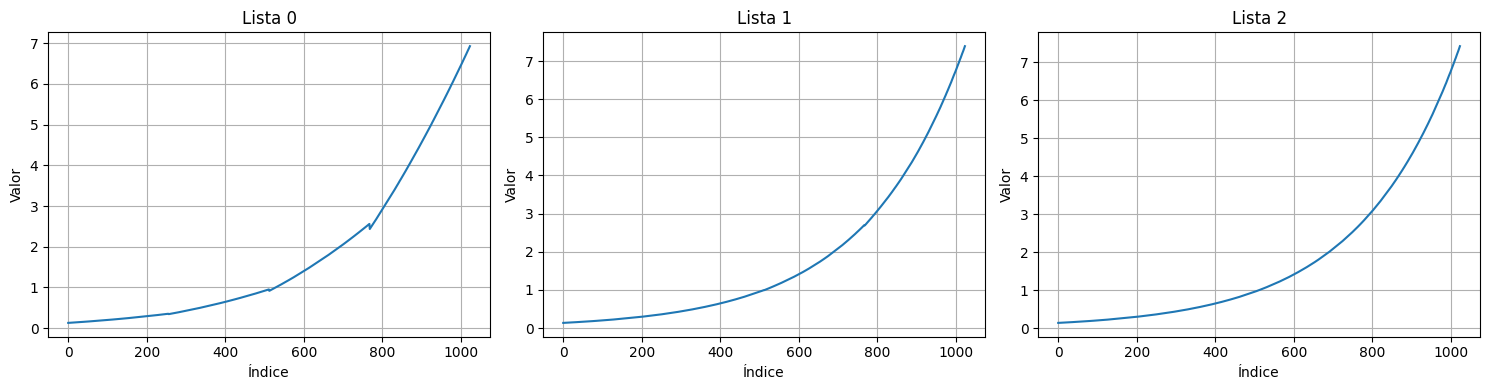

In [36]:
plot_listas(grau_3)

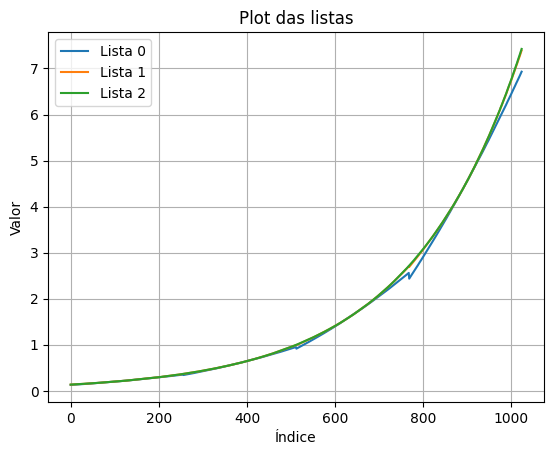

In [38]:
plot_listas_with_overlap(grau_3)

In [ ]:
from pharos_hls.pharos_hls import PharosHLS

In [ ]:
vitis_explore = PharosHLS("z_estudo_EXP")

In [ ]:
from pharos_hls.constraints import *
from pharos_hls.params import *

params = {
    "grau": Param(range=(1, 3)),
    "newton": Param(range=(1, 3))
}

function_params = {
    "input": FunctionParam("input_t", input_or_output=True),
    "output": FunctionParam("output_t", input_or_output=True),
    "padeP": CustomVectorParam("operation_t", "grau", get_P),
    "padeQ": CustomVectorParam("operation_t", "grau", get_Q)
}

In [ ]:
IMPL_FOLDER = "z_estudo_EXP_user_impl"

In [8]:
vitis_explore.define_function_to_explore("pade_with_division",
                                         f"{IMPL_FOLDER}/approx_exp_func.h",
                                         params,
                                         function_params,
                                         ("grau", "newton"))

In [9]:
vitis_explore.define_testbench(f"{IMPL_FOLDER}/testbench.cpp")

In [ ]:
vitis_explore.explore_synth(frequency_MHz=100, number_of_samples=9, part="xcu250-figd2104-2L-e", simulate_with_testbench=True)

In [15]:
tb_output = vitis_explore.get_tb_output("pade_with_division")

In [16]:
def get_max_relative_abs_error(approx_values, real_values):
    max_error = -1
    idx = -1

    for i in range(len(real_values)):
        aux = abs(real_values[i] - approx_values[i]) / abs(real_values[i])

        if aux > max_error:
            max_error = aux
            idx = i

    return max_error, idx

def get_max_abs_error(approx_values, real_values):
    max_error = -1
    idx = -1

    for i in range(len(real_values)):
        aux = abs(real_values[i] - approx_values[i])

        if aux > max_error:
            max_error = aux
            idx = i

    return max_error, idx

def get_mse(approx_values, real_values):
    sum = 0

    for i in range(len(real_values)):
        aux = real_values[i] - approx_values[i]
        sum += aux * aux

    return sum / len(real_values)

tb_output.sort(key=lambda x: (x["config"]["grau"], x["config"]["newton"]))

for config_output in tb_output:

    if config_output['config']['grau'] == 1:
        continue

    max_relative, idx_relative = get_max_relative_abs_error(config_output['out'], gabarito)
    max_abs, idx_abs = get_max_abs_error(config_output['out'], gabarito)
    mse = get_mse(config_output['out'], gabarito)

    print(f"{config_output['config']}: max relative error ({-2 + idx_relative / 256: .4f}): {max_relative: .4f}   -   max absolute error ({-2 + idx_abs/ 256: .4f}): {max_abs: .4f}  -  MSE: {mse:.4f}")


{'grau': 2, 'newton': 1}: max relative error (-2.0000):  0.0535   -   max absolute error ( 1.9961):  0.3749  -  MSE: 0.0047
{'grau': 2, 'newton': 2}: max relative error (-2.0000):  0.0535   -   max absolute error ( 1.9961):  0.3749  -  MSE: 0.0047
{'grau': 2, 'newton': 3}: max relative error (-2.0000):  0.0535   -   max absolute error ( 1.9961):  0.3749  -  MSE: 0.0047
{'grau': 3, 'newton': 1}: max relative error ( 1.9883):  0.0090   -   max absolute error ( 1.9883):  0.0657  -  MSE: 0.0002
{'grau': 3, 'newton': 2}: max relative error ( 1.9883):  0.0090   -   max absolute error ( 1.9883):  0.0657  -  MSE: 0.0002
{'grau': 3, 'newton': 3}: max relative error ( 1.9883):  0.0090   -   max absolute error ( 1.9883):  0.0657  -  MSE: 0.0002


In [ ]:
from pharos_hls.pharos_hls import PharosHLS

In [ ]:
vitis_explore = PharosHLS("z_estudo_EXP")

In [ ]:
from pharos_hls.constraints import *
from pharos_hls.params import *

params = {
    "grau": Param(range=(1, 3)),
    "newton": Param(range=(1, 3))
}

function_params = {
    "input": FunctionParam("input_t", input_or_output=True),
    "output": FunctionParam("output_t", input_or_output=True)
}

In [ ]:
IMPL_FOLDER = "z_estudo_EXP_user_impl"

In [21]:
vitis_explore.define_function_to_explore("cpp_exp",
                                         f"{IMPL_FOLDER}/approx_exp_func.h",
                                         params,
                                         function_params,
                                         ("grau", "newton"))

In [22]:
vitis_explore.define_testbench(f"{IMPL_FOLDER}/testbench.cpp")

In [ ]:
vitis_explore.explore_synth(frequency_MHz=100, number_of_samples=1, part="xcu250-figd2104-2L-e", simulate_with_testbench=True)

In [ ]:
tb_output = vitis_explore.get_tb_output("pade_with_division")

In [31]:
from tabulate import tabulate
import pandas as pd

csv_pade = "z_pade/pade_xcu250-figd2104-2L-e.csv"
csv_pade_with_division = "z_pade/pade_with_division_xcu250-figd2104-2L-e.csv"
csv_cpp_exp = "z_pade/cpp_exp_xcu250-figd2104-2L-e.csv"

def make_table_from_report_all(file_name):

    df = pd.read_csv(file_name)
    # linha_filtrada = df[(df['grau'] == 3) & (df['newton'] == 3)]
    print(tabulate(df, headers="keys", tablefmt="grid", showindex=False))

def make_table_from_report(file_name):

    df = pd.read_csv(file_name)
    linha_filtrada = df[(df['grau'] == 3) & (df['newton'] == 3)]
    print(tabulate(linha_filtrada, headers="keys", tablefmt="grid", showindex=False))

print("PADE")
make_table_from_report_all(csv_pade)

print("\nPADE WITH DIVISION")
make_table_from_report(csv_pade_with_division)

print("\nCPP EXP")
make_table_from_report(csv_cpp_exp)

PADE
+--------+----------+------------+-------+------+-------+--------+--------------------+--------------------------+
|   grau |   newton |   BRAM_18K |   DSP |   FF |   LUT |   URAM |   avg_total_cycles |   estimated_clock_period |
+========+==========+============+=======+======+=======+========+====================+==========================+
|      3 |        2 |          0 |    10 |  158 |   248 |      0 |                 19 |                    5.73  |
+--------+----------+------------+-------+------+-------+--------+--------------------+--------------------------+
|      2 |        3 |          0 |    12 |  223 |   394 |      0 |                 14 |                    5.73  |
+--------+----------+------------+-------+------+-------+--------+--------------------+--------------------------+
|      1 |        1 |          0 |     4 |   29 |   123 |      0 |                  3 |                    5.464 |
+--------+----------+------------+-------+------+-------+--------+---------

In [ ]:
from pharos_hls.pharos_hls import PharosHLS

In [ ]:
vitis_explore = PharosHLS("z_estudo_EXP")

In [3]:
import math
import numpy as np

def get_lut_values_piecewise(N):

    values = []
    negative_input_values = []

    total_segs = 1 << N

    x = -2
    inc_x = 4 / total_segs

    for i in range(total_segs // 2):
        negative_input_values.append(math.exp(x))
        x += inc_x

    for i in range(total_segs // 2):
        values.append(math.exp(x))
        x += inc_x

    values.append(math.exp(2))
    values.extend(negative_input_values)
    values.append(values[0])

    return np.array(values)

In [4]:
get_lut_values_piecewise(2)

array([1.        , 2.71828183, 7.3890561 , 0.13533528, 0.36787944,
       1.        ])

In [ ]:
from pharos_hls.constraints import *
from pharos_hls.params import *

params = {
    "N": Param(range=(1, 8))
}

function_params = {
    "input": FunctionParam("input_t", input_or_output=True),
    "output": FunctionParam("output_t", input_or_output=True),
    "lut_values": CustomVectorParam("operation_t", "N", get_lut_values_piecewise)
}

In [6]:
IMPL_FOLDER = "z_estudo_EXP_user_impl"

In [7]:
vitis_explore.define_function_to_explore("piece_wise",
                                         f"{IMPL_FOLDER}/approx_exp_func.h",
                                         params,
                                         function_params,
                                         "N")

In [8]:
vitis_explore.define_testbench(f"{IMPL_FOLDER}/testbench.cpp")

In [9]:
# from vitis_explore.vitis_utils import run_csim
# run_csim("z_estudo_EXP/")

In [ ]:
vitis_explore.explore_synth(frequency_MHz=100, number_of_samples=8, part="xcu250-figd2104-2L-e", simulate_with_testbench=True)

In [11]:
tb_output = vitis_explore.get_tb_output("piece_wise")

In [12]:
print(tb_output[0])

{'config': {'N': 7}, 'out': [0.135254, 0.135742, 0.13623, 0.136719, 0.137207, 0.137695, 0.138184, 0.138672, 0.139404, 0.139893, 0.140381, 0.141113, 0.141602, 0.14209, 0.142822, 0.143311, 0.144043, 0.144531, 0.14502, 0.145508, 0.14624, 0.146729, 0.147217, 0.147705, 0.148438, 0.148926, 0.149658, 0.150146, 0.150879, 0.151367, 0.1521, 0.152588, 0.15332, 0.153809, 0.154541, 0.155029, 0.155762, 0.15625, 0.156982, 0.157471, 0.158203, 0.158691, 0.159424, 0.159912, 0.160645, 0.161133, 0.161865, 0.162354, 0.163086, 0.163574, 0.164307, 0.164795, 0.165527, 0.16626, 0.166748, 0.16748, 0.168213, 0.168701, 0.169434, 0.170166, 0.170898, 0.171387, 0.172119, 0.172852, 0.173584, 0.174072, 0.174805, 0.175537, 0.17627, 0.177002, 0.177734, 0.178467, 0.179199, 0.179688, 0.18042, 0.181152, 0.181885, 0.182617, 0.18335, 0.184082, 0.184814, 0.185547, 0.186279, 0.187012, 0.187744, 0.188477, 0.189209, 0.189941, 0.190674, 0.191406, 0.192139, 0.192871, 0.193604, 0.194336, 0.195068, 0.195801, 0.196777, 0.19751, 0.198

In [13]:
from tabulate import tabulate
import pandas as pd

csv_piece_wise = "z_estudo_EXP/piece_wise_xcu250-figd2104-2L-e.csv"

def make_table_from_report_all(file_name):

    df = pd.read_csv(file_name)
    # linha_filtrada = df[(df['grau'] == 3) & (df['newton'] == 3)]
    print(tabulate(df, headers="keys", tablefmt="grid", showindex=False))

make_table_from_report_all(csv_piece_wise)

+-----+------------+-------+------+-------+--------+--------------------+--------------------------+
|   N |   BRAM_18K |   DSP |   FF |   LUT |   URAM |   avg_total_cycles |   estimated_clock_period |
+=====+============+=======+======+=======+========+====================+==========================+
|   7 |          0 |     1 |   48 |   169 |      0 |                  5 |                    2.412 |
+-----+------------+-------+------+-------+--------+--------------------+--------------------------+
|   5 |          0 |     1 |   48 |   117 |      0 |                  5 |                    2.454 |
+-----+------------+-------+------+-------+--------+--------------------+--------------------------+
|   4 |          0 |     1 |   48 |   115 |      0 |                  5 |                    2.454 |
+-----+------------+-------+------+-------+--------+--------------------+--------------------------+
|   8 |          0 |     1 |   48 |   235 |      0 |                  5 |                  

In [20]:
import math

gabarito = []
inc = 1 / 256
value = -2

for i in range(1024):
    gabarito.append(math.exp(value))
    value += inc

print(gabarito)

[0.1353352832366127, 0.13586497055877472, 0.1363967310184996, 0.13693057272981837, 0.13746650383851944, 0.13800453252227293, 0.13854466699075552, 0.13908691548577554, 0.13963128628139898, 0.1401777876840755, 0.14072642803276533, 0.1412772156990665, 0.14183015908734253, 0.14238526663485063, 0.14294254681187055, 0.14350200812183378, 0.14406365910145327, 0.1446275083208538, 0.14519356438370257, 0.14576183592734063, 0.1463323316229146, 0.14690506017550908, 0.1474800303242793, 0.14805725084258467, 0.1486367305381225, 0.14921847825306253, 0.14980250286418162, 0.15038881328299952, 0.1509774184559146, 0.15156832736434045, 0.1521615490248429, 0.1527570924892777, 0.15335496684492847, 0.15395518121464546, 0.15455774475698483, 0.15516266666634826, 0.15576995617312325, 0.15637962254382412, 0.1569916750812332, 0.15760612312454297, 0.15822297604949842, 0.15884224326854016, 0.15946393423094812, 0.16008805842298557, 0.16071462536804407, 0.16134364462678857, 0.1619751257973035, 0.1626090785152391, 0.163

In [15]:
def get_max_relative_abs_error(approx_values, real_values):
    max_error = -1
    idx = -1

    for i in range(len(real_values)):
        aux = abs(real_values[i] - approx_values[i]) / abs(real_values[i])

        if aux > max_error:
            max_error = aux
            idx = i

    return max_error, idx

def get_max_abs_error(approx_values, real_values):
    max_error = -1
    idx = -1

    for i in range(len(real_values)):
        aux = abs(real_values[i] - approx_values[i])

        if aux > max_error:
            max_error = aux
            idx = i

    return max_error, idx

def get_mse(approx_values, real_values):
    sum = 0

    for i in range(len(real_values)):
        aux = real_values[i] - approx_values[i]
        sum += aux * aux

    return sum / len(real_values)

tb_output.sort(key=lambda x: x["config"]["N"])

for config_output in tb_output:

    max_relative, idx_relative = get_max_relative_abs_error(config_output['out'], gabarito)
    max_abs, idx_abs = get_max_abs_error(config_output['out'], gabarito)
    mse = get_mse(config_output['out'], gabarito)

    print(f"{config_output['config']}: max relative error ({-2 + idx_relative / 256: .4f}): {max_relative: .4f}   -   max absolute error ({-2 + idx_abs/ 256: .4f}): {max_abs: .4f}  -  MSE: {mse:.4f}")

{'N': 1}: max relative error ( 0.6836):  0.6071   -   max absolute error ( 1.1602):  1.5156  -  MSE: 0.6144
{'N': 2}: max relative error ( 1.4180):  0.1312   -   max absolute error ( 1.5352):  0.5757  -  MSE: 0.0509
{'N': 3}: max relative error ( 0.7266):  0.0316   -   max absolute error ( 1.7617):  0.1807  -  MSE: 0.0034
{'N': 4}: max relative error ( 0.8711):  0.0078   -   max absolute error ( 1.8789):  0.0508  -  MSE: 0.0002
{'N': 5}: max relative error (-1.7461):  0.0022   -   max absolute error ( 1.9375):  0.0135  -  MSE: 0.0000
{'N': 6}: max relative error (-1.7461):  0.0022   -   max absolute error ( 1.9688):  0.0033  -  MSE: 0.0000
{'N': 7}: max relative error (-1.9727):  0.0030   -   max absolute error ( 1.8906):  0.0008  -  MSE: 0.0000
{'N': 8}: max relative error (-1.9570):  0.0029   -   max absolute error (-1.9570):  0.0004  -  MSE: 0.0000


In [12]:
import math
import numpy as np

def get_inverse_factorials(N):

    values = []
    cur_fat = 1

    for i in range(N):
        cur_fat /= (i + 1)
        values.append(cur_fat)
    
    return np.array(values)

In [13]:
get_inverse_factorials(6)

array([1.        , 0.5       , 0.16666667, 0.04166667, 0.00833333,
       0.00138889])

In [ ]:
from pharos_hls.constraints import *
from pharos_hls.params import *

params = {
    "N": Param(range=(1, 8))
}

function_params = {
    "input": FunctionParam("input_t", input_or_output=True),
    "output": FunctionParam("output_t", input_or_output=True),
    "inv_factorials": CustomVectorParam("operation_t", "N", get_inverse_factorials)
}

In [73]:
IMPL_FOLDER = "z_estudo_EXP_user_impl"

In [74]:
vitis_explore.define_function_to_explore("maclaurin",
                                         f"{IMPL_FOLDER}/approx_exp_func.h",
                                         params,
                                         function_params,
                                         "N")

In [75]:
vitis_explore.define_testbench(f"{IMPL_FOLDER}/testbench.cpp")

In [70]:
# from vitis_explore.vitis_utils import run_csim
# run_csim("z_estudo_EXP/")

In [ ]:
vitis_explore.explore_synth(frequency_MHz=100, number_of_samples=8, part="xcu250-figd2104-2L-e", simulate_with_testbench=True)

In [77]:
tb_output = vitis_explore.get_tb_output("maclaurin")

In [78]:
def get_max_relative_abs_error(approx_values, real_values):
    max_error = -1
    idx = -1

    for i in range(len(real_values)):
        aux = abs(real_values[i] - approx_values[i]) / abs(real_values[i])

        if aux > max_error:
            max_error = aux
            idx = i

    return max_error, idx

def get_max_abs_error(approx_values, real_values):
    max_error = -1
    idx = -1

    for i in range(len(real_values)):
        aux = abs(real_values[i] - approx_values[i])

        if aux > max_error:
            max_error = aux
            idx = i

    return max_error, idx

def get_mse(approx_values, real_values):
    sum = 0

    for i in range(len(real_values)):
        aux = real_values[i] - approx_values[i]
        sum += aux * aux

    return sum / len(real_values)

tb_output.sort(key=lambda x: x["config"]["N"])

for config_output in tb_output:

    max_relative, idx_relative = get_max_relative_abs_error(config_output['out'], gabarito)
    max_abs, idx_abs = get_max_abs_error(config_output['out'], gabarito)
    mse = get_mse(config_output['out'], gabarito)

    print(f"{config_output['config']}: max relative error ({-2 + idx_relative / 256: .4f}): {max_relative: .4f}   -   max absolute error ({-2 + idx_abs/ 256: .4f}): {max_abs: .4f}  -  MSE: {mse:.4f}")

{'N': 1}: max relative error (-2.0000):  109.8358   -   max absolute error (-1.0039):  15.6297  -  MSE: 59.7503
{'N': 2}: max relative error (-2.0000):  6.3891   -   max absolute error ( 1.9961):  2.3720  -  MSE: 0.4062
{'N': 3}: max relative error (-2.0000):  1.4678   -   max absolute error ( 1.9961):  1.7099  -  MSE: 0.1742
{'N': 4}: max relative error (-2.0000):  1.8755   -   max absolute error ( 1.9961):  1.6552  -  MSE: 0.1655
{'N': 5}: max relative error (-2.0000):  1.8683   -   max absolute error ( 1.9961):  1.6544  -  MSE: 0.1653
{'N': 6}: max relative error (-2.0000):  1.8683   -   max absolute error ( 1.9961):  1.6544  -  MSE: 0.1653
{'N': 7}: max relative error (-2.0000):  1.8683   -   max absolute error ( 1.9961):  1.6544  -  MSE: 0.1653
{'N': 8}: max relative error (-2.0000):  1.8683   -   max absolute error ( 1.9961):  1.6544  -  MSE: 0.1653


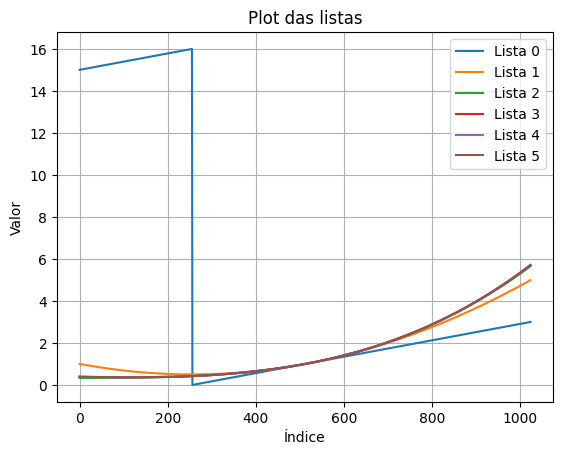

In [32]:
degrees_to_plot = []

for config_output in tb_output:
    if config_output['config']['N'] <= 7:
        degrees_to_plot.append(config_output['out'])

plot_listas_with_overlap(degrees_to_plot)

In [65]:
from tabulate import tabulate
import pandas as pd

csv_maclaurin = "z_estudo_EXP/maclaurin_xcu250-figd2104-2L-e.csv"

def make_table_from_report_all(file_name):

    df = pd.read_csv(file_name)
    # linha_filtrada = df[(df['grau'] == 3) & (df['newton'] == 3)]
    print(tabulate(df, headers="keys", tablefmt="grid", showindex=False))

make_table_from_report_all(csv_maclaurin)

+-----+------------+-------+------+-------+--------+--------------------+--------------------------+
|   N |   BRAM_18K |   DSP |   FF |   LUT |   URAM |   avg_total_cycles |   estimated_clock_period |
+=====+============+=======+======+=======+========+====================+==========================+
|   6 |          0 |     2 |   77 |   143 |      0 |                 13 |                    6.307 |
+-----+------------+-------+------+-------+--------+--------------------+--------------------------+
|   1 |          0 |     0 |    0 |    22 |      0 |                  0 |                    0.765 |
+-----+------------+-------+------+-------+--------+--------------------+--------------------------+
|   2 |          0 |     1 |   46 |   136 |      0 |                  3 |                    4.471 |
+-----+------------+-------+------+-------+--------+--------------------+--------------------------+
|   3 |          0 |     2 |   59 |   127 |      0 |                  4 |                  

In [ ]:
from pharos_hls.constraints import *
from pharos_hls.params import *

params = {
    "N": Param(range=(1, 8))
}

function_params = {
    "input": FunctionParam("input_t", input_or_output=True),
    "output": FunctionParam("output_t", input_or_output=True),
}

In [95]:
IMPL_FOLDER = "z_estudo_EXP_user_impl"

In [96]:
vitis_explore.define_function_to_explore("maclaurin_coeff_on_demand",
                                         f"{IMPL_FOLDER}/approx_exp_func.h",
                                         params,
                                         function_params,
                                         "N")

In [97]:
vitis_explore.define_testbench(f"{IMPL_FOLDER}/testbench.cpp")

In [92]:
# from vitis_explore.vitis_utils import run_csim
# run_csim("z_estudo_EXP/")

In [ ]:
vitis_explore.explore_synth(frequency_MHz=100, number_of_samples=8, part="xcu250-figd2104-2L-e", simulate_with_testbench=True)

In [99]:
tb_output = vitis_explore.get_tb_output("maclaurin_coeff_on_demand")

In [100]:
def get_max_relative_abs_error(approx_values, real_values):
    max_error = -1
    idx = -1

    for i in range(len(real_values)):
        aux = abs(real_values[i] - approx_values[i]) / abs(real_values[i])

        if aux > max_error:
            max_error = aux
            idx = i

    return max_error, idx

def get_max_abs_error(approx_values, real_values):
    max_error = -1
    idx = -1

    for i in range(len(real_values)):
        aux = abs(real_values[i] - approx_values[i])

        if aux > max_error:
            max_error = aux
            idx = i

    return max_error, idx

def get_mse(approx_values, real_values):
    sum = 0

    for i in range(len(real_values)):
        aux = real_values[i] - approx_values[i]
        sum += aux * aux

    return sum / len(real_values)

tb_output.sort(key=lambda x: x["config"]["N"])

for config_output in tb_output:

    max_relative, idx_relative = get_max_relative_abs_error(config_output['out'], gabarito)
    max_abs, idx_abs = get_max_abs_error(config_output['out'], gabarito)
    mse = get_mse(config_output['out'], gabarito)

    print(f"{config_output['config']}: max relative error ({-2 + idx_relative / 256: .4f}): {max_relative: .4f}   -   max absolute error ({-2 + idx_abs/ 256: .4f}): {max_abs: .4f}  -  MSE: {mse:.4f}")

{'N': 1}: max relative error (-2.0000):  109.8358   -   max absolute error (-1.0039):  15.6297  -  MSE: 59.7503
{'N': 2}: max relative error (-2.0000):  6.3891   -   max absolute error ( 1.9961):  2.3759  -  MSE: 0.4067
{'N': 3}: max relative error (-2.0000):  114.8005   -   max absolute error (-1.6016):  15.7979  -  MSE: 25.0234
{'N': 4}: max relative error (-2.0000):  1.4823   -   max absolute error ( 1.9961):  0.4008  -  MSE: 0.0087
{'N': 5}: max relative error (-1.9961):  0.5184   -   max absolute error ( 1.9961):  0.1400  -  MSE: 0.0009
{'N': 6}: max relative error (-2.0000):  0.1744   -   max absolute error ( 1.9648):  0.0559  -  MSE: 0.0001
{'N': 7}: max relative error (-1.9805):  0.0695   -   max absolute error ( 1.9648):  0.0344  -  MSE: 0.0000
{'N': 8}: max relative error (-2.0000):  0.0337   -   max absolute error ( 1.9648):  0.0293  -  MSE: 0.0000


In [101]:
from tabulate import tabulate
import pandas as pd

csv_maclaurin_coeff_on_demand = "z_estudo_EXP/maclaurin_coeff_on_demand_xcu250-figd2104-2L-e.csv"

def make_table_from_report_all(file_name):

    df = pd.read_csv(file_name)
    # linha_filtrada = df[(df['grau'] == 3) & (df['newton'] == 3)]
    print(tabulate(df, headers="keys", tablefmt="grid", showindex=False))

make_table_from_report_all(csv_maclaurin_coeff_on_demand)

+-----+------------+-------+------+-------+--------+--------------------+--------------------------+
|   N |   BRAM_18K |   DSP |   FF |   LUT |   URAM |   avg_total_cycles |   estimated_clock_period |
+=====+============+=======+======+=======+========+====================+==========================+
|   3 |          0 |     1 |  422 |   333 |      0 |                 17 |                    4.029 |
+-----+------------+-------+------+-------+--------+--------------------+--------------------------+
|   8 |          0 |     1 |  423 |   336 |      0 |                 22 |                    4.029 |
+-----+------------+-------+------+-------+--------+--------------------+--------------------------+
|   1 |          0 |     0 |    0 |    22 |      0 |                  0 |                    0.765 |
+-----+------------+-------+------+-------+--------+--------------------+--------------------------+
|   4 |          0 |     1 |  422 |   333 |      0 |                 18 |                  

In [14]:
from tabulate import tabulate
import pandas as pd

csv_pade_without_unroll = "z_estudo_EXP/pade_without_unroll_xcu250-figd2104-2L-e.csv"
csv_pade_with_unroll = "z_estudo_EXP/pade_xcu250-figd2104-2L-e.csv"

def make_table_from_report_all(file_name):

    df = pd.read_csv(file_name)
    # linha_filtrada = df[(df['grau'] == 3) & (df['newton'] == 3)]
    print(tabulate(df, headers="keys", tablefmt="grid", showindex=False))

print("Pade with unroll")
make_table_from_report_all(csv_pade_with_unroll)

print("\nPade without unroll")

make_table_from_report_all(csv_pade_without_unroll)

Pade with unroll
+--------+----------+------------+-------+------+-------+--------+--------------------+--------------------------+
|   grau |   newton |   BRAM_18K |   DSP |   FF |   LUT |   URAM |   avg_total_cycles |   estimated_clock_period |
+========+==========+============+=======+======+=======+========+====================+==========================+
|      3 |        2 |          0 |    10 |  158 |   248 |      0 |                 19 |                    5.73  |
+--------+----------+------------+-------+------+-------+--------+--------------------+--------------------------+
|      2 |        3 |          0 |    12 |  223 |   394 |      0 |                 14 |                    5.73  |
+--------+----------+------------+-------+------+-------+--------+--------------------+--------------------------+
|      1 |        1 |          0 |     4 |   29 |   123 |      0 |                  3 |                    5.464 |
+--------+----------+------------+-------+------+-------+------